In [8]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [9]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

#normalization
x_train=x_train/255.0
x_test=x_test/255.0

# converts labels into one-hot encoded vectors
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test,10)

print("x_train shape:",x_train.shape)
print("y_train shape:", y_train.shape)



x_train shape: (60000, 28, 28)
y_train shape: (60000, 10)


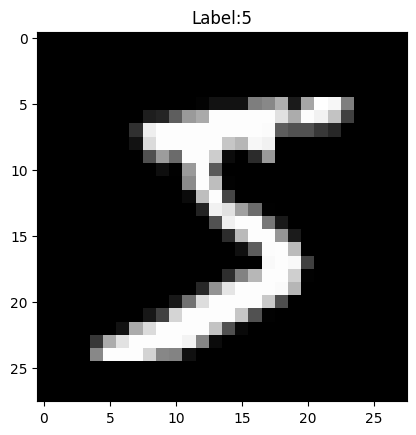

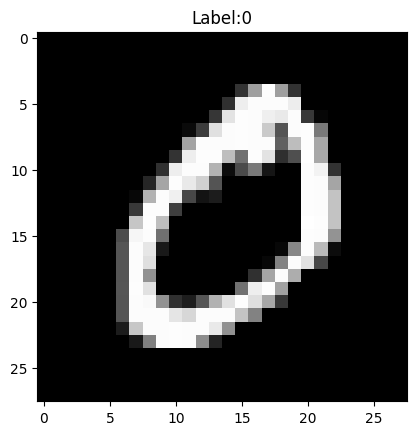

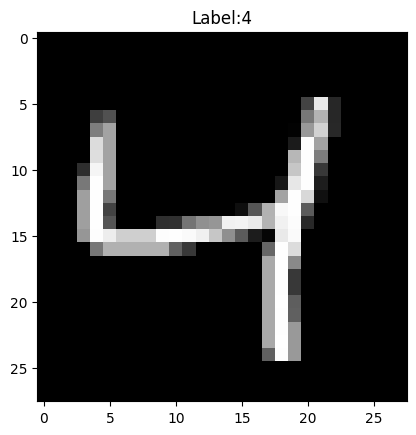

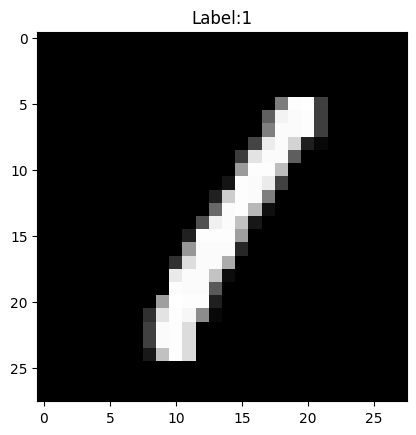

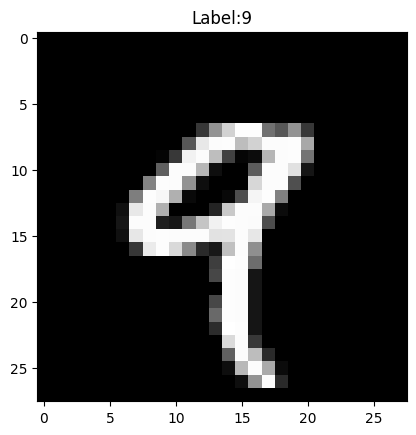

In [10]:
# Plot first 5 images
#cmap- colormap
'''Your data (like x_train[i]) is already an image matrix
imshow() displays it

cmap just tells:

“which color should represent each value?”'''

for i in range(5):
    plt.imshow(x_train[i],cmap='gray')
    plt.title(f"Label:{y_train[i].argmax()}")
    plt.show()

In [11]:
model = Sequential([
    Flatten(input_shape=(28, 28)),   # convert 28x28 → 784
    Dense(128, activation='relu'),   # hidden layer
    Dense(10, activation='softmax')  # output layer (10 classes)
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/home/shahidkx07/machine_learning/venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1777912827.816710   15141 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777912827.825661   15141 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [12]:
# Train the model
training_history = model.fit(x_train, y_train, epochs=5, validation_split=0.1)



Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9229 - loss: 0.2712 - val_accuracy: 0.9648 - val_loss: 0.1286
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9644 - loss: 0.1191 - val_accuracy: 0.9720 - val_loss: 0.0947
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9754 - loss: 0.0814 - val_accuracy: 0.9765 - val_loss: 0.0822
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9814 - loss: 0.0596 - val_accuracy: 0.9775 - val_loss: 0.0800
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9855 - loss: 0.0460 - val_accuracy: 0.9798 - val_loss: 0.0686


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.9774 - loss: 0.0753
Test Accuracy: 0.977400004863739
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step


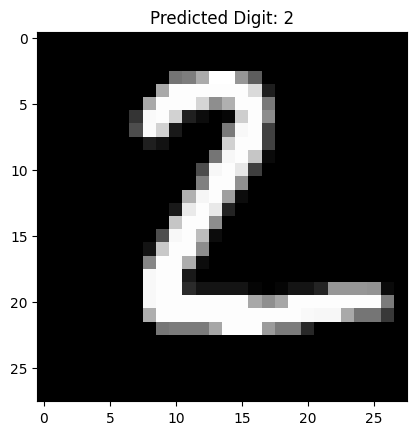

In [13]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# Predict example
predictions = model.predict(x_test)

# Display one prediction
plt.imshow(x_test[1], cmap='gray')
plt.title(f"Predicted Digit: {predictions[1].argmax()}")
plt.show()

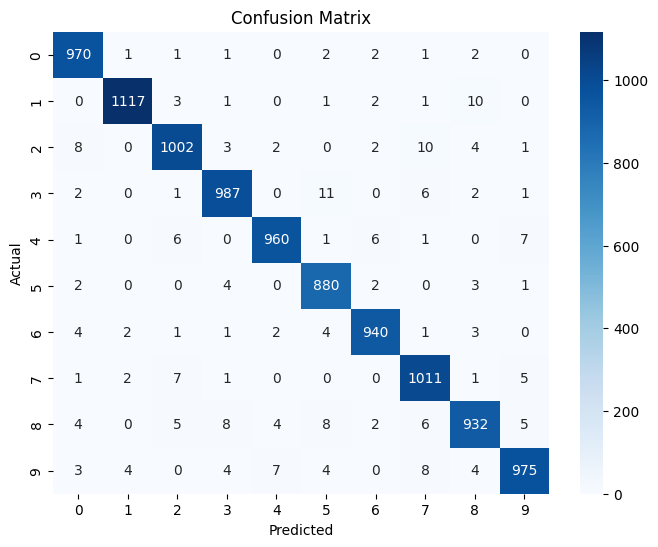

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Convert one-hot to labels
#np.argmax() returns the index of the maximum value in an array.
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

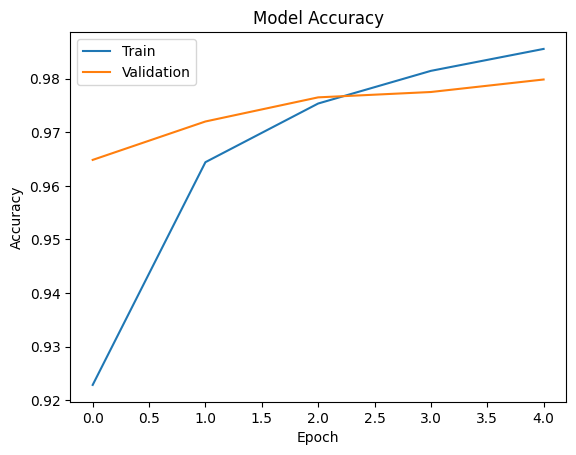

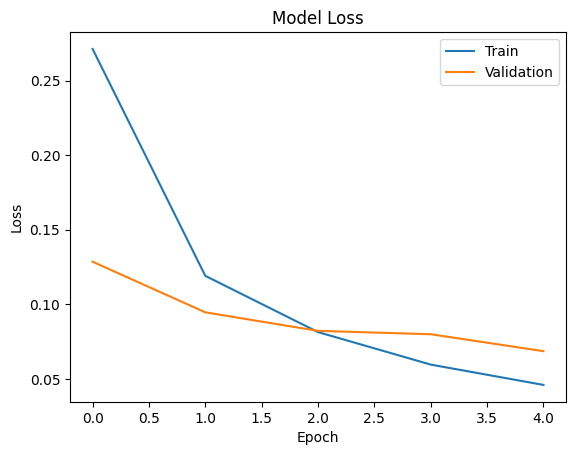

In [15]:
# Accuracy plot
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.plot(training_history.history['loss'])
plt.plot(training_history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.98      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.99      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.96      0.96       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

